# 01 — Hai công thức khoảng cách và giới hạn của chúng

Notebook 00 cho thấy một camera chỉ biết **hướng**, không biết **tỉ lệ**. Notebook này dựng
hai cách bổ sung tỉ lệ bằng hình học thuần tuý, rút ra sai số của từng cách, rồi đo trên
nhãn KITTI xem thực tế lệch khỏi lý thuyết ở đâu. Cả hai công thức đều không cần huấn luyện;
chúng là mốc để so với mạng học ở notebook 04.

| Mục | Câu hỏi |
|---|---|
| 1. Kích thước đã biết | $Z = fH/h$ từ đâu ra, cần giả định gì? |
| 2. Lan truyền sai số | Sai 1 pixel hay sai chiều cao 10% thì khoảng cách sai bao nhiêu? |
| 3. Hiệu ứng chiều dài xe | Vì sao công thức sai khoảng 9% ngay cả khi mọi thứ hoàn hảo? |
| 4. Mặt phẳng sàn | $Z = f\,h_{cam}/(v_2 - c_y)$ từ đâu ra, vì sao nó hỏng trên KITTI? |
| 5. Hai công thức trên nhãn và trên bộ nhận diện | Con số cuối cùng của dự án |

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from monodist import kitti, geometry, evaluate

ROOT = Path("../data/kitti_tracking")
RESULTS = Path("../results")
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})

def objects(split):
    """Every Car / Pedestrian label of a split as flat arrays (camera-2 frame)."""
    rows = {k: [] for k in ("seq", "cls", "box", "dim", "loc", "ry", "trunc", "occ", "f", "cy")}
    for s in kitti.SPLIT[split]:
        lab, P = kitti.load_labels(ROOT, s), kitti.load_calib(ROOT, s)
        k = kitti.intrinsics(P)
        m = np.isin(lab["type"], kitti.CLASSES)
        n = m.sum()
        rows["seq"] += [s] * n
        rows["cls"] += [kitti.CLASSES.index(t) for t in lab["type"][m]]
        rows["box"].append(lab["box"][m]); rows["dim"].append(lab["dim"][m])
        rows["loc"].append(kitti.to_camera2(lab["loc"][m], P)); rows["ry"].append(lab["ry"][m])
        rows["trunc"].append(lab["trunc"][m]); rows["occ"].append(lab["occ"][m])
        rows["f"] += [k["f"]] * n; rows["cy"] += [k["cy"]] * n
    return {k: np.concatenate(v) if isinstance(v[0], np.ndarray) else np.array(v) for k, v in rows.items()}

train, test = objects("train"), objects("test")
print({k: len(train["cls"]) for k in ["train objects"]}, {k: len(test["cls"]) for k in ["test objects"]})

{'train objects': 22852} {'test objects': 7653}


## 1. Kích thước đã biết

**Dựng công thức.** Một vật đứng thẳng, đỉnh ở toạ độ dọc $Y_{\text{đỉnh}}$, đáy ở
$Y_{\text{đáy}}$, cả hai ở cùng độ sâu $Z$. Theo phép chiếu lỗ kim (notebook 00):

$$v_1 = f\,\frac{Y_{\text{đỉnh}}}{Z} + c_y,\qquad v_2 = f\,\frac{Y_{\text{đáy}}}{Z} + c_y
\;\Longrightarrow\; h = v_2 - v_1 = f\,\frac{Y_{\text{đáy}} - Y_{\text{đỉnh}}}{Z} = \frac{fH}{Z}.$$

Đảo lại:

$$\boxed{\hat Z = \frac{f\,H}{h}}$$

**Ký hiệu mới**
- $v_1, v_2$: dòng pixel của cạnh trên và cạnh dưới khung; $h = v_2 - v_1$: chiều cao khung (pixel)
- $H$: chiều cao thật của vật (mét) · $\hat Z$: khoảng cách *ước lượng* (dấu mũ = ước lượng)

**Ba giả định**, mỗi giả định là một nguồn sai số:
1. **Biết $H$.** Thực tế chỉ biết chiều cao *trung bình* của lớp.
2. **Đỉnh và đáy ở cùng độ sâu.** Đúng với một cái cột; sai với một chiếc xe dài 4 m (mục 3).
3. **Khung bao đúng chiều cao của vật.** Sai khi vật bị mép ảnh cắt hoặc bị che.

Dự án lấy $H$ là trung bình chiều cao nhãn trên **tập train** (không nhìn tập test):

In [2]:
H = [float(train["dim"][train["cls"] == c, 0].mean()) for c in range(2)]
for c, name in enumerate(kitti.CLASSES):
    h_c = train["dim"][train["cls"] == c, 0]
    print(f"{name:10s} H mean {h_c.mean():.3f} m, std {h_c.std():.3f} m ({h_c.std() / h_c.mean():.1%})")
print("same as evaluate.constants:", np.allclose(H, evaluate.constants(ROOT)["class_height"]))

Car        H mean 1.522 m, std 0.152 m (10.0%)
Pedestrian H mean 1.739 m, std 0.093 m (5.3%)
same as evaluate.constants: True


## 2. Lan truyền sai số

**Công cụ: đạo hàm của logarit.** Nếu $Z = fH/h$ thì $\ln Z = \ln f + \ln H - \ln h$. Lấy vi
phân hai vế, và nhớ $d(\ln x) = dx/x$:

$$\frac{dZ}{Z} = \frac{dH}{H} - \frac{dh}{h}.$$

Nghĩa là **sai số tương đối cộng lại** (với dấu). Đây là lý do dự án đo sai số bằng
**AbsRel** $= |\hat Z - Z|/Z$: công thức này sinh ra sai số tỉ lệ với $Z$, nên đo theo
phần trăm mới so được vật gần với vật xa.

**Khi nào dùng được.** Vi phân là xấp xỉ bậc nhất, tốt khi sai số nhỏ (dưới khoảng 20%).

**Áp vào số của dự án.**
- $dH/H$: chiều cao ô tô lệch chuẩn 10,0% quanh trung bình, người 5,3% (ô code trên). Chỉ riêng
  nguồn này đã cho sai số điển hình cỡ đó, **không phụ thuộc khoảng cách**.
- $dh/h$: khung sai $\delta$ pixel. Vì $h = fH/Z$ nhỏ dần khi vật xa, cùng $\delta$ gây sai
  số lớn dần: $\;|dh/h| = \delta Z/(fH)$.

In [3]:
f = 721.5
for dist in (10, 20, 40, 60):
    h_car = f * H[0] / dist
    print(f"Z = {dist:2d} m: car box h = {h_car:5.1f} px -> a 2 px box error is {2 / h_car:5.1%} of Z")

Z = 10 m: car box h = 109.8 px -> a 2 px box error is  1.8% of Z
Z = 20 m: car box h =  54.9 px -> a 2 px box error is  3.6% of Z
Z = 40 m: car box h =  27.5 px -> a 2 px box error is  7.3% of Z
Z = 60 m: car box h =  18.3 px -> a 2 px box error is 10.9% of Z


Ở 60 m một chiếc xe chỉ cao khoảng 18 pixel, nên 2 pixel sai lệch đã thành 11%. Đây là lý do
vật xa khó đo, dù hình học không đổi.

## 3. Hiệu ứng chiều dài xe

Kiểm tra giả định 2 bằng cách cho công thức **mọi thứ hoàn hảo**: chiều cao thật của đúng
vật đó, khung bao của nhãn, chỉ lấy vật không bị cắt và không bị che.

In [4]:
m = (train["trunc"] == 0) & (train["occ"] == 0) & (train["loc"][:, 2] > 5)
h_box = train["box"][:, 3] - train["box"][:, 1]
ratio = train["f"] * train["dim"][:, 0] / h_box / train["loc"][:, 2]       # Zhat / Z with the true H
for c, name in enumerate(kitti.CLASSES):
    r = ratio[m & (train["cls"] == c)]
    print(f"{name:10s} Zhat/Z with true H and label box: median {np.median(r):.3f}, "
          f"|error| median {np.median(np.abs(r - 1)):.1%}")

Car        Zhat/Z with true H and label box: median 0.917, |error| median 8.3%
Pedestrian Zhat/Z with true H and label box: median 0.963, |error| median 3.9%


Ô tô bị **ước lượng thấp khoảng 8–9%** ngay cả khi không có sai số nào; người đi bộ lệch ít
hơn nhiều. Nguyên nhân nằm ở chỗ khung 2D bao **toàn bộ** hộp 3D, trong khi nhãn đo độ sâu
đến **tâm** hộp.

**Rút ra công thức.** Xét một chiếc xe nhìn từ phía sau: dài $l$, cao $H$, tâm ở độ sâu $z$,
đáy thấp hơn camera $y$ mét (camera cao hơn nóc xe, nên $y > H$).
- Cạnh **dưới** của khung là chỗ thấp nhất trên ảnh, tức đáy của **mặt gần** (độ sâu
  $z - l/2$): $\;v_2 = c_y + f\,\dfrac{y}{z - l/2}$.
- Cạnh **trên** là chỗ cao nhất trên ảnh. Nóc xe thấp hơn camera $y - H$ (dương), và điểm đó
  lên cao nhất khi ở **xa** nhất (độ sâu $z + l/2$): $\;v_1 = c_y + f\,\dfrac{y - H}{z + l/2}$.

Vậy

$$\frac{h}{f} = \frac{y}{z - l/2} - \frac{y - H}{z + l/2}
\approx \frac{H}{z} + \frac{l}{2z}\cdot\frac{2y - H}{z}
\quad\Longrightarrow\quad
\frac{\hat Z}{z} = \frac{fH/h}{z} \approx \frac{1}{1 + \dfrac{l}{2z}\cdot\dfrac{2y - H}{H}}.$$

(Bước xấp xỉ dùng $\tfrac{1}{z \mp l/2} \approx \tfrac{1}{z}(1 \pm \tfrac{l}{2z})$, đúng khi $l \ll z$.)

**Ký hiệu mới**
- $l$: chiều dài xe · $y$: độ sâu của mặt đường dưới xe *theo chiều dọc*, tức camera cao hơn
  điểm chạm đất bao nhiêu mét

Với $y = 1{,}6$ m, $H = 1{,}5$ m thì $(2y - H)/H \approx 1{,}13$; xe dài $4{,}3$ m ở 25 m cho
$\tfrac{l}{2z} \cdot 1{,}13 \approx 9{,}7\%$. Kiểm chứng trên các xe đang chạy **dọc** trục quang
học (hướng xe gần song song với trục $z$, tức $|\cos r_y|$ nhỏ):

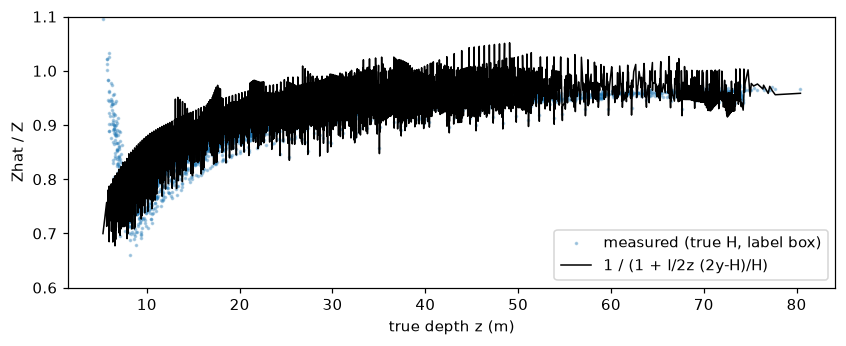

5937 cars seen from behind or front: median |measured - theory| = 0.030


In [5]:
car = m & (train["cls"] == 0) & (np.abs(np.cos(train["ry"])) < 0.2)
z, l, Hc, y = train["loc"][car, 2], train["dim"][car, 2], train["dim"][car, 0], train["loc"][car, 1]
theory = 1 / (1 + l / (2 * z) * (2 * y - Hc) / Hc)
measured = ratio[car]
order = np.argsort(z)
plt.scatter(z, measured, s=2, alpha=0.3, label="measured (true H, label box)")
plt.plot(z[order], theory[order], color="k", lw=1, label="1 / (1 + l/2z (2y-H)/H)")
plt.xlabel("true depth z (m)"); plt.ylabel("Zhat / Z"); plt.ylim(0.6, 1.1); plt.legend(); plt.show()
print(f"{car.sum()} cars seen from behind or front: median |measured - theory| = {np.median(np.abs(measured - theory)):.3f}")

Lý thuyết bám sát dữ liệu: sai số giảm dần theo $1/z$, đúng như công thức. Xe nhìn nghiêng
cũng bị hiệu ứng tương tự với chiều dài hiệu dụng khác đi.

**Hệ quả ngược đời (xuất hiện trong kết quả cuối):** bộ nhận diện càng giống nhãn thì công
thức càng sai. Khung của YOLO huấn luyện trên COCO không ôm trọn chiều dài xe như nhãn KITTI;
sau fine-tune, khung giống nhãn hơn, và sai số của công thức kích thước với ô tô không bị cắt **tăng**
từ 7,9% lên 9,8% trên phép chia cố định (kiểm định chéo 3 phần ở README: từ 8,7% lên 10,6%). Sai số đó không đến từ bộ nhận diện kém đi, mà từ giả định 2 của công thức.

## 4. Mặt phẳng sàn

**Dựng công thức.** Giả sử mặt đường phẳng, camera đặt ngang (trục quang học song song mặt
đường) ở độ cao $h_{cam}$. Điểm chạm đất của vật ở độ sâu $Z$ có toạ độ dọc $Y = h_{cam}$, nên

$$v_2 = c_y + f\,\frac{h_{cam}}{Z} \;\Longrightarrow\; \boxed{\hat Z = \frac{f\,h_{cam}}{v_2 - c_y}}$$

Dòng $v = c_y$ là **đường chân trời**: điểm chạm đất ở vô cực. Công thức không dùng chiều cao
vật, chỉ dùng **vị trí cạnh dưới**.

**Ký hiệu mới**
- $h_{cam}$: độ cao camera so với mặt đường (dự án lấy trung vị trên nhãn ô tô tập train)

**Độ nhạy.** Lấy vi phân như mục 2: $\;\dfrac{dZ}{Z} = -\dfrac{dv_2}{v_2 - c_y} = -\,dv_2\cdot\dfrac{Z}{f\,h_{cam}}$.
Sai số **tăng tuyến tính theo khoảng cách**. Hai nguồn sai của $v_2$:
- khung sai $\delta$ pixel;
- camera **chúi** một góc $\theta$ (xe phanh, lên dốc): đường chân trời dịch khoảng $f\tan\theta$ pixel.

In [6]:
h_cam = evaluate.constants(ROOT)["cam_height"]
print(f"h_cam from the train cars: {h_cam:.3f} m")
for dist in (10, 20, 40, 60):
    per_px = dist / (f * h_cam)
    print(f"Z = {dist:2d} m: 1 px of bottom-edge error -> {per_px:5.1%};  0.5 deg of pitch ({f * np.tan(np.radians(0.5)):.1f} px) -> {per_px * f * np.tan(np.radians(0.5)):5.1%}")

h_cam from the train cars: 1.512 m
Z = 10 m: 1 px of bottom-edge error ->  0.9%;  0.5 deg of pitch (6.3 px) ->  5.8%
Z = 20 m: 1 px of bottom-edge error ->  1.8%;  0.5 deg of pitch (6.3 px) -> 11.5%
Z = 40 m: 1 px of bottom-edge error ->  3.7%;  0.5 deg of pitch (6.3 px) -> 23.1%
Z = 60 m: 1 px of bottom-edge error ->  5.5%;  0.5 deg of pitch (6.3 px) -> 34.6%


Chỉ nửa độ chúi đã thành 23% sai số ở 40 m. Giả định "mặt đường phẳng, camera ngang" chịu
đựng kém hơn nhiều so với giả định "biết chiều cao vật".

**Mặt đường KITTI phẳng đến đâu?** Toạ độ $y$ của điểm chạm đất trong nhãn chính là độ cao
camera so với mặt đất *tại chỗ vật đứng*. Nếu đường phẳng, mọi vật cho cùng một $y$:

Car        ground point below the camera: median 1.61 m, interquartile range 1.38-1.80 m
Pedestrian ground point below the camera: median 1.45 m, interquartile range 1.29-1.55 m


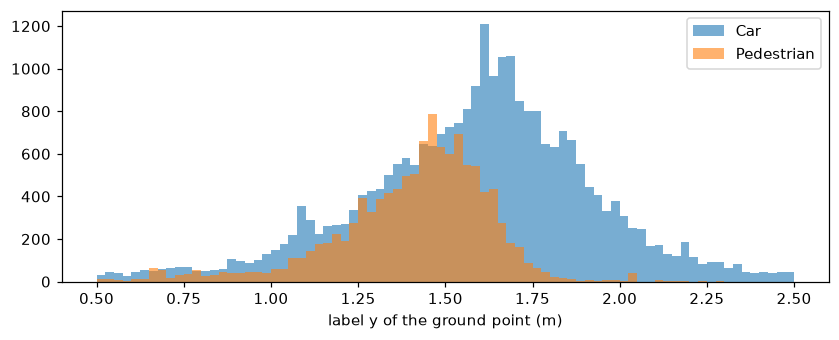

In [7]:
alln = objects("train"), objects("val"), objects("test")
y_all = np.concatenate([o["loc"][:, 1] for o in alln]); c_all = np.concatenate([o["cls"] for o in alln])
for c, name in enumerate(kitti.CLASSES):
    q = np.percentile(y_all[c_all == c], [25, 50, 75])
    print(f"{name:10s} ground point below the camera: median {q[1]:.2f} m, interquartile range {q[0]:.2f}-{q[2]:.2f} m")
plt.hist(y_all[c_all == 0], bins=80, range=(0.5, 2.5), alpha=0.6, label="Car")
plt.hist(y_all[c_all == 1], bins=80, range=(0.5, 2.5), alpha=0.6, label="Pedestrian")
plt.xlabel("label y of the ground point (m)"); plt.legend(); plt.show()

- Với ô tô, điểm chạm đất dao động **1,38–1,80 m** dưới camera (khoảng tứ phân vị, tức 50%
  giá trị ở giữa). Đó là dốc, xe chúi và khúc cua; lệch 0,2 m trên 1,6 m đã là 13% sai số.
- Người đi bộ đứng cao hơn ô tô khoảng **16 cm** (trung vị 1,45 so với 1,61 m), đúng cỡ một bậc vỉa hè. Công thức không biết
  điều này, nên với người đi bộ nó ước lượng thấp có hệ thống.
- Thêm vào đó, cạnh dưới của khung ô tô là đáy của **mặt gần**, không phải của tâm, nên hiệu ứng
  chiều dài ở mục 3 cũng tác động lên công thức này.

## 5. Hai công thức trên nhãn và trên bộ nhận diện

`results/eval/*.json` chứa sai số của cả hai công thức trong hai tình huống: trên **khung của
nhãn** (bộ nhận diện hoàn hảo, tức sàn sai số của công thức) và trên **khung thật của bộ nhận
diện**, cùng những vật đó.

In [8]:
r = json.loads((RESULTS / "eval" / "coco_1280.json").read_text())
rows = []
for method in ("size", "ground"):
    for src, key in (("label boxes", "distance_on_label_boxes"), ("COCO detector", "distance")):
        d = r[key][method]
        rows.append((method, src, *(d[g]["absrel_mean"][0] for g in
                     ("Car not truncated", "Car 10-20 m", "Car 20-40 m", "Car >40 m", "Pedestrian not truncated"))))
print(f"{'method':7s} {'boxes':14s} {'car ok':>7s} {'car10-20':>9s} {'car20-40':>9s} {'car>40':>7s} {'ped ok':>7s}")
for row in rows:
    print(f"{row[0]:7s} {row[1]:14s} " + " ".join(f"{v:8.1%}" for v in row[2:]))

method  boxes           car ok  car10-20  car20-40  car>40  ped ok
size    label boxes        8.9%    13.3%     7.1%     4.7%     5.9%
size    COCO detector      7.9%     9.5%     6.7%     7.8%     8.1%
ground  label boxes       28.7%    20.7%    28.4%    41.0%    29.2%
ground  COCO detector     26.9%    18.9%    28.8%    35.1%    31.5%


Đọc bảng (AbsRel trung bình):
- **Kích thước đã biết** có sàn khoảng 9% với ô tô và tốt dần khi xa, đúng như công thức
  $l/2z$ ở mục 3. Khung COCO còn cho kết quả *tốt hơn* sàn một chút với ô tô không bị cắt:
  khung của nó thấp hơn khung nhãn, vô tình bù một phần hiệu ứng chiều dài. Ngược lại, ở trên
  40 m khung COCO kém hơn sàn (7,8% so với 4,7%): ở đó vài pixel sai của khung (mục 2) mới là
  nguồn sai chính.
- **Mặt phẳng sàn** tệ ở mọi nơi và tệ hơn khi xa, đúng như độ nhạy $Z/(f\,h_{cam})$.
- Không công thức nào xử lý được **vật bị cắt mép**: khung khi đó không còn đo chiều cao vật.
  Mạng ở notebook 04 có một đặc trưng báo "khung chạm mép" và học cách xử lý trường hợp này.

## Tóm tắt

- Kích thước đã biết: $\hat Z = fH/h$; sai số tương đối $\tfrac{dZ}{Z} = \tfrac{dH}{H} - \tfrac{dh}{h}$.
- Với ô tô có một sàn sai số khoảng 9% vì khung bao cả chiều dài xe:
  $\hat Z/z \approx 1/\big(1 + \tfrac{l}{2z}\cdot\tfrac{2y-H}{H}\big)$, đã kiểm chứng trên nhãn.
- Mặt phẳng sàn: $\hat Z = f\,h_{cam}/(v_2 - c_y)$; sai số tăng tuyến tính theo khoảng cách,
  và mặt đường KITTI không phẳng (1,38–1,80 m), người đứng trên vỉa hè cao hơn 16 cm.
- Cả hai là mốc; notebook 04 cho thấy một mạng nhỏ đọc cùng khung bao làm tốt hơn cả hai.